# Notebook 01 - EDA & Topic Discovery

**Goal:** load and clean the external (AG News) and internal (CNN/DailyMail) corpora, explore them,
and discover the prominent topics in the external content using BERTopic. These topics become the
fixed vocabulary used for coverage and gap analysis in notebook 02.

Sections: 1) load & clean, 2) EDA, 3) topic discovery.

## Setup

Config, seeds and device selection. Everything downstream reads paths and hyperparameters from
`CONFIG` so the notebook has one place to tune.

In [1]:
# Setup: fix the Apple Silicon crash, set up the folders, load the libraries, fix the random seed and pick the device (GPU or CPU).
# CONFIG keeps all the settings in one place.
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")   # prevents Apple Silicon crash
os.environ.setdefault("OMP_NUM_THREADS", "1")
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.environ["HF_HOME"] = str(ROOT / "hf_cache")           # models/datasets downloaded once, stored here
DATA_DIR, CACHE_DIR, OUTPUTS_DIR, EVAL_DIR = (ROOT / d for d in ("data", "cache", "outputs", "eval"))
for d in (DATA_DIR, CACHE_DIR, OUTPUTS_DIR, EVAL_DIR): d.mkdir(exist_ok=True)
from dotenv import load_dotenv; load_dotenv(ROOT / ".env")  # OPENAI_API_KEY

import re
import html
import random
import time
from collections import Counter

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
elif torch.backends.mps.is_available():
    DEVICE = "mps"
else:
    DEVICE = "cpu"
print(f"Using device: {DEVICE}")

CONFIG = {
    "seed": SEED,
    "device": DEVICE,
    "data_dir": DATA_DIR,
    "cache_dir": CACHE_DIR,
    "outputs_dir": OUTPUTS_DIR,
    "emb_model": "sentence-transformers/all-MiniLM-L6-v2",
    "emb_dim": 384,
    "emb_max_tokens": 256,
    "emb_batch_size": 64,
    "umap_n_neighbors": 15,
    "umap_n_components": 5,
    "umap_min_dist": 0.0,
    "hdbscan_min_cluster_size": 150,
    "vectorizer_min_df": 10,
    "max_topics_before_reduce": 40,
    "target_topics": 25,
    "llm_provider": os.environ.get("LLM_PROVIDER", "openai"),
    "llm_model": os.environ.get("LLM_MODEL", "gpt-4o-mini"),
}

OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "")
HAS_LLM_KEY = bool(OPENAI_API_KEY) and OPENAI_API_KEY != "REPLACE_ME"
print(f"LLM key configured: {HAS_LLM_KEY}")

CONFIG

Using device: mps
LLM key configured: True


{'seed': 42,
 'device': 'mps',
 'data_dir': PosixPath('/Users/shubhamyadav/Desktop/topic_modelling/case-study/data'),
 'cache_dir': PosixPath('/Users/shubhamyadav/Desktop/topic_modelling/case-study/cache'),
 'outputs_dir': PosixPath('/Users/shubhamyadav/Desktop/topic_modelling/case-study/outputs'),
 'emb_model': 'sentence-transformers/all-MiniLM-L6-v2',
 'emb_dim': 384,
 'emb_max_tokens': 256,
 'emb_batch_size': 64,
 'umap_n_neighbors': 15,
 'umap_n_components': 5,
 'umap_min_dist': 0.0,
 'hdbscan_min_cluster_size': 150,
 'vectorizer_min_df': 10,
 'max_topics_before_reduce': 40,
 'target_topics': 25,
 'llm_provider': 'openai',
 'llm_model': 'gpt-4o-mini'}

## 1. Load & clean

### 1.1 AG News (external content)

Load train + test, keep labels 2 (Business) and 3 (Sci/Tech). We inspect a handful of raw rows
first so cleaning only touches artifacts that are actually present.

In [32]:
# Download AG News (train + test), keep only the Business and Sci/Tech rows, and look at the first few.
from datasets import load_dataset

try:
    ag_raw = load_dataset("fancyzhx/ag_news")
except Exception as e:
    print(f"fancyzhx/ag_news failed ({e!r}); falling back to ag_news")
    ag_raw = load_dataset("ag_news")

ag_df = pd.concat(
    [ag_raw["train"].to_pandas(), ag_raw["test"].to_pandas()], ignore_index=True
)
AG_LABEL_NAMES = {0: "World", 1: "Sports", 2: "Business", 3: "Sci/Tech"}
ag_df["label_name"] = ag_df["label"].map(AG_LABEL_NAMES)
ag_df = ag_df[ag_df["label"].isin([2, 3])].reset_index(drop=True)
print(f"AG News rows (Business + Sci/Tech): {len(ag_df):,}")
ag_df.head(3)

AG News rows (Business + Sci/Tech): 63,800


,text,label,label_name
0,Wall St. Bears Claw Back Into the Black (Reute...,2,Business
1,Carlyle Looks Toward Commercial Aerospace (Reu...,2,Business
2,Oil and Economy Cloud Stocks' Outlook (Reuters...,2,Business


In [33]:
# Inspect raw samples for cleaning artifacts
for t in ag_df["text"].sample(10, random_state=SEED):
    print(repr(t))
    print("---")

"Sun's fighting chance Forrester CEO George Colony argues that if Sun goes down, it's going to go down taking very big swings."
---
'Insurers Lose \\$21 Billion from Hurricanes including hurricanes Charley, Frances, Ivan, and Jeanne -- contributed to \\$21.3 billion in insured property loss claims, says actuarial firm ISO.'
---
'Microsoft Launches Regional Versions of Hotmail Microsoft Corp., the world #39;s largest software maker, has expanded its flagship MSN Hotmail internet email service to include European and Japanese domain names, it said on Friday.'
---
'Fujifilm FinePix F450 Attracts Praise from Outside Camera Circle The Fujifilm FinePix F450 attracted the attention of some popular magazines this month. Fortune named the digital camera one of the Top 25 Best Products of the Year '
---
'Job figures disappoint in Mass. The Massachusetts economic recovery remained stagnant last month as the unemployment rate dipped slightly, but employers sliced payrolls for the third time in fou

Artifacts observed: stray literal backslashes (`\\`) used as line-wrap markers, mangled HTML
entities missing their leading `&` (`#36;` for `$`, `#39;` for `'`, `quot;` for `"`), and wire-service
datelines/source tags such as `(Reuters) Reuters -`, `NEW YORK (Reuters) -`, `(AP) AP -`. We strip
exactly these - nothing else was found in the sample.

A second scan of the cleaned data found more leftovers: HTML tags (`<b>`, `<A HREF=...>`, `<FONT>`), `amp;` and `hellip;` without their `&`, and number codes such as `#151;` (a dash) and `#146;` (an apostrophe). The cleaning function now handles these too.

In [34]:
# Clean the AG text: fix broken HTML pieces, remove news-agency tags like (Reuters) and extra spaces.
# Then look at a few rows to check the cleaning worked.
AG_SOURCE_TAG_RE = re.compile(
    r"\(?[A-Za-z.' ]{2,20}\)?\s+(?:Reuters|AP|AFP|USATODAY\.com|Forbes\.com|Reuters\.com)\s*-\s*"
)
AG_DATELINE_RE = re.compile(
    r"\b[A-Z][A-Za-z.' /]{1,25}\(([A-Za-z.' ]{2,20})\)\s*-\s*"
)

def clean_ag_text(text: str) -> str:
    text = re.sub(r"(?<![&\w])(amp|hellip|nbsp|lt|gt|#\d+);", r"&\1;", text)  # entities missing their leading &
    text = html.unescape(text)
    text = re.sub(r"<[^>]*(?:>|$)", " ", text)  # leftover HTML tags such as <b>, <A HREF=...>, <FONT>
    text = text.replace("&#36;", "$").replace("#36;", "$")
    text = text.replace("&#39;", "\u2019").replace("#39;", "\u2019")
    text = text.replace("&quot;", '"').replace("quot;", '"')
    text = text.replace("\\", " ")
    text = AG_SOURCE_TAG_RE.sub(" ", text)
    text = AG_DATELINE_RE.sub(" ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

ag_df["text_clean"] = ag_df["text"].map(clean_ag_text)
ag_df[["text", "text_clean"]].sample(5, random_state=SEED)

,text,text_clean
16443,Sun's fighting chance Forrester CEO George Col...,Sun's fighting chance Forrester CEO George Col...
39858,Insurers Lose \$21 Billion from Hurricanes inc...,Insurers Lose $21 Billion from Hurricanes incl...
48147,Microsoft Launches Regional Versions of Hotmai...,Microsoft Launches Regional Versions of Hotmai...
57862,Fujifilm FinePix F450 Attracts Praise from Out...,Fujifilm FinePix F450 Attracts Praise from Out...
59949,Job figures disappoint in Mass. The Massachuse...,Job figures disappoint in Mass. The Massachuse...


In [35]:
# Drop empty rows and exact duplicates, then save the cleaned AG data for the later notebooks.
n_before = len(ag_df)
ag_df["text_clean"] = ag_df["text_clean"].str.strip()
ag_df = ag_df[ag_df["text_clean"].str.len() > 0]
n_after_empty = len(ag_df)
n_dupes = ag_df.duplicated(subset=["text_clean"]).sum()
ag_df = ag_df.drop_duplicates(subset=["text_clean"]).reset_index(drop=True)
n_final = len(ag_df)
ag_n_dupes = n_dupes

print(f"AG News: {n_before:,} rows -> dropped {n_before - n_after_empty:,} empty -> "
      f"dropped {n_dupes:,} exact duplicates -> {n_final:,} final rows")

ag_out = ag_df[["label", "label_name", "text_clean"]].rename(columns={"text_clean": "text"})
ag_out.to_parquet(DATA_DIR / "ag_clean.parquet", index=False)
print(f"Saved {DATA_DIR / 'ag_clean.parquet'}")

AG News: 63,800 rows -> dropped 0 empty -> dropped 404 exact duplicates -> 63,396 final rows
Saved /Users/shubhamyadav/Desktop/topic_modelling/case-study/data/ag_clean.parquet


### 1.2 CNN/DailyMail (internal content)

Load all splits (Arrow-backed `Dataset`, memory-mapped - never materialized as one pandas
DataFrame of full articles). We keep `id`, `article`, `highlights` and inspect raw samples first.

In [36]:
# Download CNN/DailyMail (all splits joined into one). The first source fails with newer library versions,
# so we fall back to the same data from another repo.
from datasets import concatenate_datasets

try:
    cnn_raw = load_dataset("ccdv/cnn_dailymail", "3.0.0")
except Exception as e:
    print(f"ccdv/cnn_dailymail failed ({e!r}); falling back to abisee/cnn_dailymail")
    cnn_raw = load_dataset("abisee/cnn_dailymail", "3.0.0")

cnn_all = concatenate_datasets([cnn_raw["train"], cnn_raw["validation"], cnn_raw["test"]])
cnn_all = cnn_all.select_columns(["id", "article", "highlights"])
print(f"CNN/DailyMail total rows: {len(cnn_all):,}")

ccdv/cnn_dailymail failed (RuntimeError('Dataset scripts are no longer supported, but found cnn_dailymail.py')); falling back to abisee/cnn_dailymail
CNN/DailyMail total rows: 311,971


In [37]:
# Print 10 random CNN articles and highlights to see what extra text needs cleaning.
rng = random.Random(SEED)
sample_idx = rng.sample(range(len(cnn_all)), 10)
for i in sample_idx:
    row = cnn_all[i]
    print("ARTICLE:", repr(row["article"][:200]))
    print("HIGHLIGHTS:", repr(row["highlights"][:200]))
    print("---")

ARTICLE: '(CNN) -- A magnitude 7.9 earthquake struck off the coast of central Peru on Wednesday evening, killing 15 people and leaving 70 hurt, President Alan Garcia said on national television. Pedestrians try'
HIGHLIGHTS: "NEW: Tsunami warnings and watches canceled, as is Hawaii's advisory .\nAt least 15 people killed, 70 injured in quake .\nQuake was felt for two minutes; people ran out of office buildings in panic .\nBro"
---
ARTICLE: "(CNN) -- Argentina's Juan Martin Del Potro made a disappointing comeback from injury at the Thailand Open in Bangkok on Tuesday, where he was defeated 7-6 6-4 by Olivier Rochus of Belgium in the openi"
HIGHLIGHTS: "Juan Martin Del Potro loses on comeback to tennis after wrist injury .\nArgentine ace was playing first match since Australian Open in January .\nBelgium's Olivier Rochus beats Del Potro in straight set"
---
ARTICLE: 'By . Daily Mail Reporter . PUBLISHED: . 07:24 EST, 22 December 2013 . | . UPDATED: . 08:19 EST, 22 December 2013 . Behind b

Two boilerplate patterns are present in the article text: a CNN dateline (`(CNN) --`,
`LONDON, England (CNN) --`) and a Daily Mail byline/timestamp header
(`By . <author> . PUBLISHED: . <date> . | . UPDATED: . <date> .`). Many articles have neither.
The `highlights` field has no boilerplate - it's already clean bullet-style summary sentences -
so we only clean `article`.

In [38]:
# Cleaning rules for CNN: remove the (CNN) dateline and the Daily Mail 'By ... PUBLISHED' header.
# Test on 4 samples to see before and after.
CNN_DATELINE_RE = re.compile(
    r"^([A-Z][A-Za-z.' ]{1,20}(?:,\s*[A-Za-z.' ]{2,20})?\s*)?\((?:CNN|Reuters|AP|AFP)\)\s*--\s*"
)
DAILYMAIL_HEADER_RE = re.compile(
    r"^By\s*\.\s*.+?\.\s*PUBLISHED\s*:\s*\.\s*.+?\.\s*"
    r"(?:\|\s*\.\s*UPDATED\s*:\s*\.\s*.+?\.\s*)?"
)

def clean_article_text(text: str) -> str:
    text = html.unescape(text)
    text = DAILYMAIL_HEADER_RE.sub("", text)
    text = CNN_DATELINE_RE.sub("", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_highlights(text: str) -> str:
    text = html.unescape(text)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

# quick before/after check on the boilerplate patterns
test_examples = [cnn_all[i]["article"][:250] for i in sample_idx]
for ex in test_examples[:4]:
    print("BEFORE:", repr(ex))
    print("AFTER :", repr(clean_article_text(ex)[:200]))
    print("---")

BEFORE: '(CNN) -- A magnitude 7.9 earthquake struck off the coast of central Peru on Wednesday evening, killing 15 people and leaving 70 hurt, President Alan Garcia said on national television. Pedestrians try to make calls on their cell phones in Lima, Peru,'
AFTER : 'A magnitude 7.9 earthquake struck off the coast of central Peru on Wednesday evening, killing 15 people and leaving 70 hurt, President Alan Garcia said on national television. Pedestrians try to make '
---
BEFORE: "(CNN) -- Argentina's Juan Martin Del Potro made a disappointing comeback from injury at the Thailand Open in Bangkok on Tuesday, where he was defeated 7-6 6-4 by Olivier Rochus of Belgium in the opening round. The 22-year-old has not played on the AT"
AFTER : "Argentina's Juan Martin Del Potro made a disappointing comeback from injury at the Thailand Open in Bangkok on Tuesday, where he was defeated 7-6 6-4 by Olivier Rochus of Belgium in the opening round."
---
BEFORE: 'By . Daily Mail Reporter . PUBLISHED: .

In [39]:
# Apply the cleaning to every article and highlight, in batches so it stays fast and light on memory.
def clean_batch(batch):
    return {
        "article_clean": [clean_article_text(a) for a in batch["article"]],
        "highlights_clean": [clean_highlights(h) for h in batch["highlights"]],
    }

cnn_all = cnn_all.map(clean_batch, batched=True, batch_size=1000, desc="Cleaning CNN/DailyMail")
cnn_all

Dataset({
    features: ['id', 'article', 'highlights', 'article_clean', 'highlights_clean'],
    num_rows: 311971
})

In [40]:
# Find rows with empty or duplicate highlights and drop them.
cnn_df_meta = cnn_all.select_columns(["id", "highlights_clean"]).to_pandas()
n_before = len(cnn_df_meta)

empty_mask = cnn_df_meta["highlights_clean"].str.len() == 0
n_empty = int(empty_mask.sum())

dup_mask = cnn_df_meta["highlights_clean"].duplicated()
n_dupes = int(dup_mask.sum())

keep_mask = (~empty_mask) & (~dup_mask)
n_final = int(keep_mask.sum())

print(f"CNN/DailyMail: {n_before:,} rows -> dropped {n_empty:,} empty highlights -> "
      f"dropped {n_dupes:,} exact duplicate highlights -> {n_final:,} final rows")

keep_ids = set(cnn_df_meta.loc[keep_mask, "id"])
cnn_all = cnn_all.filter(lambda ex: ex["id"] in keep_ids, desc="Dropping empty/duplicate rows")
len(cnn_all)

CNN/DailyMail: 311,971 rows -> dropped 0 empty highlights -> dropped 5,058 exact duplicate highlights -> 306,913 final rows


306913

In [41]:
# Keep only id, article and highlights, and save the cleaned CNN data.
cnn_all = cnn_all.rename_columns({"article": "article_raw", "highlights": "highlights_raw"})
cnn_all = cnn_all.rename_columns({"article_clean": "article", "highlights_clean": "highlights"})
cnn_all = cnn_all.select_columns(["id", "article", "highlights"])

cnn_all.to_parquet(str(DATA_DIR / "cnn_clean.parquet"))
print(f"Saved {DATA_DIR / 'cnn_clean.parquet'} ({len(cnn_all):,} rows)")

Creating parquet from Arrow format:   0%|          | 0/14 [00:00<?, ?ba/s]

Saved /Users/shubhamyadav/Desktop/topic_modelling/case-study/data/cnn_clean.parquet (306,913 rows)


## 2. EDA

### 2.1 AG News (external)

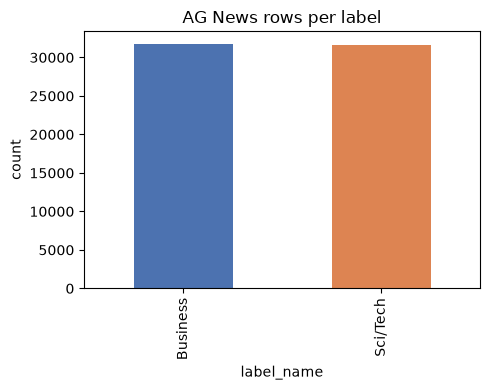

label_name
Business    31801
Sci/Tech    31595
Name: count, dtype: int64

In [42]:
# EDA: bar chart of how many AG rows are Business and how many are Sci/Tech.
fig, ax = plt.subplots(figsize=(5, 4))
ag_out["label_name"].value_counts().plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("AG News rows per label")
ax.set_ylabel("count")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ag_label_counts.png", dpi=150)
plt.show()
ag_out["label_name"].value_counts()

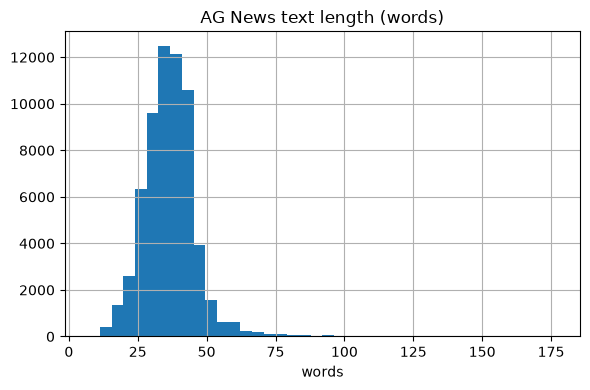

count    63396.000000
mean        36.670232
std         10.430739
min          7.000000
25%         31.000000
50%         36.000000
75%         41.000000
max        177.000000
Name: n_words, dtype: float64

In [43]:
# EDA: how long the AG texts are (words per text). Histogram plus summary numbers.
ag_out["n_words"] = ag_out["text"].str.split().str.len()

fig, ax = plt.subplots(figsize=(6, 4))
ag_out["n_words"].hist(bins=40, ax=ax)
ax.set_title("AG News text length (words)")
ax.set_xlabel("words")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "ag_length_dist.png", dpi=150)
plt.show()
ag_out["n_words"].describe()

In [44]:
# Show how many AG duplicates were removed while cleaning.
print(f"AG News exact duplicates removed during cleaning: {ag_n_dupes}")

AG News exact duplicates removed during cleaning: 404


In [45]:
# Find the most common words (unigrams) and word pairs (bigrams) for each AG label. Common words like 'the' are ignored.
from sklearn.feature_extraction.text import CountVectorizer

def top_ngrams(texts, ngram_range, top_n=20):
    vec = CountVectorizer(stop_words="english", ngram_range=ngram_range, max_features=5000)
    X = vec.fit_transform(texts)
    counts = np.asarray(X.sum(axis=0)).ravel()
    vocab = vec.get_feature_names_out()
    order = np.argsort(-counts)[:top_n]
    return pd.DataFrame({"ngram": vocab[order], "count": counts[order]})

for label in ag_out["label_name"].unique():
    subset = ag_out.loc[ag_out.label_name == label, "text"]
    print(f"--- {label}: top unigrams ---")
    display(top_ngrams(subset, (1, 1)))
    print(f"--- {label}: top bigrams ---")
    display(top_ngrams(subset, (2, 2)))

--- Business: top unigrams ---


,ngram,count
0,said,7757
1,oil,6489
2,new,4923
3,company,4570
4,prices,4371
5,percent,3574
6,year,3512
7,corp,3266
8,million,3063
9,profit,2947


--- Business: top bigrams ---


,ngram,count
0,oil prices,2627
1,new york,1497
2,wall street,1074
3,quote profile,1018
4,profile research,1016
5,chief executive,934
6,united states,750
7,crude oil,733
8,said monday,697
9,federal reserve,657


--- Sci/Tech: top unigrams ---


,ngram,count
0,new,7400
1,microsoft,5451
2,said,3878
3,software,3841
4,internet,3520
5,company,3095
6,space,2793
7,search,2453
8,security,2347
9,computer,2341


--- Sci/Tech: top bigrams ---


,ngram,count
0,open source,938
1,microsoft corp,761
2,search engine,675
3,washingtonpost com,529
4,windows xp,517
5,mobile phone,515
6,space station,437
7,said tuesday,436
8,said thursday,417
9,video game,414


In [46]:
# Look at 5 random cleaned AG rows as a quick check.
ag_out[["label_name", "text"]].sample(5, random_state=SEED)

,label_name,text
14181,Sci/Tech,Take Kerry's Swift Boat for a Nonpolitical Spi...
273,Sci/Tech,Chandra Celebrates Five Years of Scientific Br...
902,Business,OFT invites comment on Telegraph deal The Offi...
45622,Sci/Tech,McAfee Battles Spyware With Enterprise Add-On ...
38151,Business,Bristol-Myers Posts Bristol-Myers Squibb Co. B...


### 2.2 CNN/DailyMail (internal)

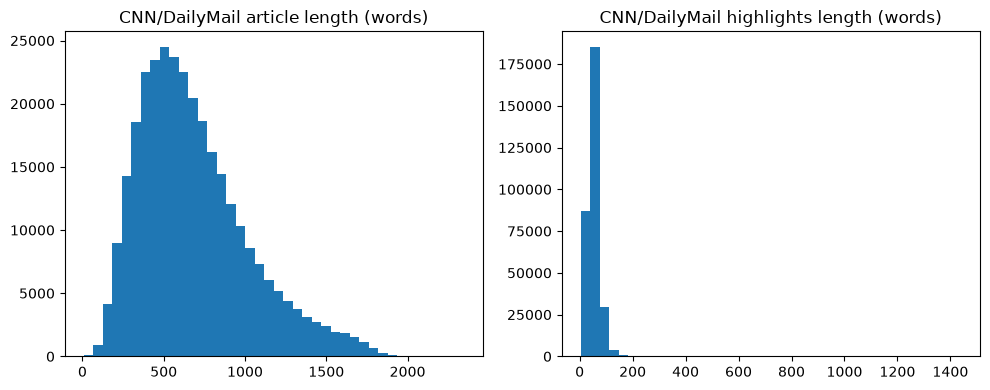

,article_words,highlight_words
count,306913.000000,306913.000000
mean,686.111826,52.030921
std,336.701337,21.646649
min,8.000000,4.000000
25%,436.000000,38.000000
50%,624.000000,49.000000
75%,871.000000,60.000000
max,2347.000000,1440.000000


In [47]:
# EDA: length of the CNN articles and highlights in words. Histograms plus summary numbers.
cnn_lengths = cnn_all.select_columns(["article", "highlights"]).map(
    lambda b: {
        "article_words": [len(a.split()) for a in b["article"]],
        "highlight_words": [len(h.split()) for h in b["highlights"]],
    },
    batched=True,
    batch_size=2000,
    desc="Measuring lengths",
)
article_words = np.array(cnn_lengths["article_words"])
highlight_words = np.array(cnn_lengths["highlight_words"])

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(article_words, bins=40)
axes[0].set_title("CNN/DailyMail article length (words)")
axes[1].hist(highlight_words, bins=40)
axes[1].set_title("CNN/DailyMail highlights length (words)")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "cnn_length_dist.png", dpi=150)
plt.show()
pd.DataFrame({"article_words": article_words, "highlight_words": highlight_words}).describe()

In [48]:
# Show how many duplicate CNN highlights were removed.
print(f"CNN/DailyMail exact duplicate highlights removed during cleaning: {n_dupes}")

CNN/DailyMail exact duplicate highlights removed during cleaning: 5058


In [49]:
# Most common words and word pairs in the CNN highlights (same method as for AG).
cnn_highlights_list = cnn_all["highlights"]
print(f"Materialized {len(cnn_highlights_list):,} highlight strings for n-gram counting "
      f"({sum(len(h) for h in cnn_highlights_list) / 1e6:.1f} MB of text)")

for label, texts in [("CNN/DailyMail highlights", cnn_highlights_list)]:
    print(f"--- {label}: top unigrams ---")
    display(top_ngrams(texts, (1, 1)))
    print(f"--- {label}: top bigrams ---")
    display(top_ngrams(texts, (2, 2)))

Materialized 306,913 highlight strings for n-gram counting (91.2 MB of text)
--- CNN/DailyMail highlights: top unigrams ---


,ngram,count
0,says,70745
1,year,51468
2,new,48188
3,said,45488
4,police,32034
5,old,31637
6,years,25417
7,000,25076
8,say,24001
9,people,22883


--- CNN/DailyMail highlights: top bigrams ---


,ngram,count
0,year old,25266
1,new york,6215
2,world cup,5246
3,premier league,5043
4,manchester united,4346
5,police say,3730
6,years ago,3156
7,prime minister,2907
8,manchester city,2655
9,real madrid,2639


In [50]:
# Look at 3 random CNN articles with their highlights.
for i in rng.sample(range(len(cnn_all)), 3):
    row = cnn_all[i]
    print("ARTICLE   :", row["article"][:200])
    print("HIGHLIGHTS:", row["highlights"][:200])
    print("---")

ARTICLE   : It has boosted loved lives across the world - but new research suggests men who take Viagra may significantly increase their risk of skin cancer. American researchers found those who took sildenafil, 
HIGHLIGHTS: Impotence drug may affect the same genetic mechanism that enables skin cancer to become more invasive, say U.S. researchers . Men who took Viagra even once had double the risk of developing melanoma .
---
ARTICLE   : A man opened fire at a Texas roller skating rink during a birthday party for one of his children, killing his estranged wife and four of her family members before turning the gun on himself, police sa
HIGHLIGHTS: NEW: Authorities say Tan Do and his wife were hosting the party . NEW: Neither of the couple's children were hurt . NEW: About 30 people were attending the party .
---
ARTICLE   : Would you be OK with a mosque in your community? According to a new national poll, most Americans say yes, they would. A CNN/Opinion Research Corporation survey foun

### 2.3 External vs. internal length comparison

Comparing AG News body text to CNN/DailyMail **highlights** (not full articles) justifies using
highlights for topic assignment: they are much closer in length to AG News items than full articles
are, so the same embedding model (max 256 tokens) captures them comparably.

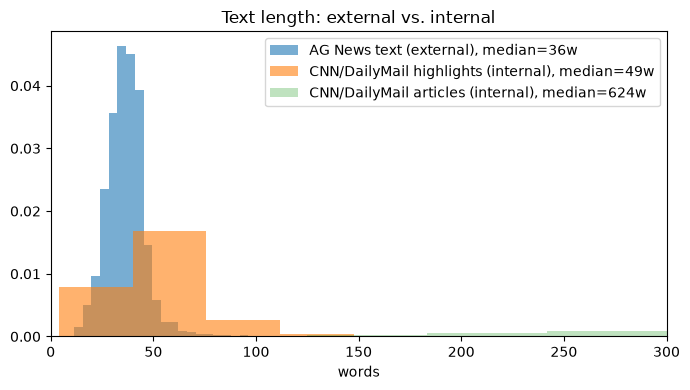

In [51]:
# Compare lengths on one chart: AG text vs CNN highlights vs full CNN articles.
# This shows why we use highlights (not full articles) to match topics.
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ag_out["n_words"], bins=40, alpha=0.6, label=f"AG News text (external), median={ag_out.n_words.median():.0f}w", density=True)
ax.hist(highlight_words, bins=40, alpha=0.6, label=f"CNN/DailyMail highlights (internal), median={np.median(highlight_words):.0f}w", density=True)
ax.hist(article_words, bins=40, alpha=0.3, label=f"CNN/DailyMail articles (internal), median={np.median(article_words):.0f}w", density=True)
ax.set_xlim(0, 300)
ax.set_xlabel("words")
ax.set_title("Text length: external vs. internal")
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "length_comparison.png", dpi=150)
plt.show()

### 2.5 EDA insights

- AG News here has only two labels, Business (31,801 rows) and Sci/Tech (31,595 rows), so the split is almost even. It is not all news.
- CNN/DailyMail is general news (crime, sport, politics, family stories), so most of it has nothing to do with tech.
- Cleaning: AG News went from 63,800 to 63,396 rows after dropping 404 duplicates. CNN went from 311,971 to 306,913 rows after dropping 5,058 duplicate highlights. No empty rows were found in either.
- A second scan of AG News found leftover HTML: tags like `<b>` and `<A HREF=...>` in 3,856 rows (about 6%), a broken `amp;` in 1,349 rows, and number codes like `#151;` in 374 rows. We extended the cleaning and checked again, and none of these are left.
- AG News texts are short: median 36 words, and most are between 31 and 41. CNN highlights are close to that (median 49 words), but full CNN articles are far longer (median 624 words, about 17 times an AG text). That is why we match topics using highlights, and keep the full articles for the RAG step.
- The top words and word pairs above are counted on all categories, not just tech. Business shows "oil prices" (2,627 times) and "wall street" (1,074). Sci/Tech shows Microsoft (5,451 times), software (3,841), "open source" (938) and "search engine" (675). CNN shows "says" (70,745), "police" (32,034) and sport terms like "world cup" (5,246) and "premier league" (5,043).
- A few word pairs are still page labels or source tags from the news sites, such as "quote profile" (1,018) and "profile research" (1,016) in Business and "washingtonpost com" (529) in Sci/Tech. They are not real topics, and are too few to change the results.
- These word counts are only to get a feel for the data. Before BERTopic we apply the tech filter (section 3), so the topics are built from tech news only.
- Both datasets are old, so "emerging topics" here means topics from that time, not today's news.

## 3. Topic discovery

We embed the AG News text with `all-MiniLM-L6-v2` (normalized, so dot product = cosine similarity)
and fit BERTopic with explicit UMAP + HDBSCAN + CountVectorizer components on the precomputed
embeddings.


In [52]:
# Load the embedding model (all-MiniLM-L6-v2). It turns text into numbers, so texts with similar meaning end up close together.
from sentence_transformers import SentenceTransformer

embed_model = SentenceTransformer(CONFIG["emb_model"], device=DEVICE)
print(f"Loaded {CONFIG['emb_model']} on {DEVICE}")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loaded sentence-transformers/all-MiniLM-L6-v2 on mps


### 3.2 Embed AG News (cached)

In [53]:
# Turn every AG text into an embedding. This takes a few minutes, so we save it and reuse it next time.
ag_emb_path = CACHE_DIR / "ag_emb.npy"
ag_texts = ag_out["text"].tolist()

if ag_emb_path.exists():
    ag_embeddings = np.load(ag_emb_path)
    print(f"Loaded cached AG News embeddings: {ag_embeddings.shape}")
else:
    t0 = time.time()
    ag_embeddings = embed_model.encode(
        ag_texts, batch_size=CONFIG["emb_batch_size"], show_progress_bar=True,
        normalize_embeddings=True,
    )
    print(f"Embedded {len(ag_texts):,} AG News docs in {time.time() - t0:.1f}s")
    np.save(ag_emb_path, ag_embeddings)
ag_embeddings.shape

Batches:   0%|          | 0/991 [00:00<?, ?it/s]

Embedded 63,396 AG News docs in 146.7s


(63396, 384)

### Tech filter

Each AG News row goes to the closest of 4 group descriptions (cosine similarity). Only rows that land on `tech` are used for topic discovery. The group embeddings are saved so notebook 02 applies the same filter to the internal side.

In [54]:
# Tech filter: describe 4 groups in words, then put each AG row in the group it is closest to by meaning.
# We keep only the tech rows for topic modelling. The group embeddings and mask are saved so notebook 02 uses the same filter on CNN.
# It also prints the group counts and 25 tech + 25 non-tech rows so we can check by eye.
GROUPS = {
  "tech": "Technology news: software, computers, internet, websites, search engines, mobile phones, "
          "wireless and telecom, cybersecurity, computer viruses and spam, data and databases, "
          "artificial intelligence, and technology companies such as Microsoft, IBM, Google, Apple, "
          "Intel and Oracle, including their products and acquisitions.",
  "business": "General business and economy news: stock markets, oil prices, banks, insurance, "
              "airlines, retail sales, jobs, interest rates, budgets and taxes, company profits and "
              "earnings reports, corporate fraud and executive pay, layoffs and job cuts, car makers, "
              "steel, aerospace and defense contracts, and mergers between non-tech companies.",
  "science": "Science and health news: space exploration, NASA, climate and environment, animals, "
             "medicine, drugs, disease and scientific research.",
  "general": "General news: politics, elections, crime, courts, war, sport, celebrities, "
             "entertainment, weather and accidents.",
}
group_emb_path = CACHE_DIR / "group_emb.npy"
tech_mask_path = CACHE_DIR / "ag_tech_mask.npy"

if group_emb_path.exists() and tech_mask_path.exists():
    group_emb = np.load(group_emb_path)
    ag_is_tech = np.load(tech_mask_path)
    print("Loaded group_emb.npy and ag_tech_mask.npy")
else:
    group_emb = embed_model.encode(list(GROUPS.values()), normalize_embeddings=True)
    np.save(group_emb_path, group_emb)                       # notebook 02 reuses this
    ag_is_tech = (ag_embeddings @ group_emb.T).argmax(axis=1) == 0
    np.save(tech_mask_path, ag_is_tech)

ag_group = (ag_embeddings @ group_emb.T).argmax(axis=1)
print(pd.Series(np.array(list(GROUPS))[ag_group]).value_counts())

print("--- 25 random TECH rows ---")
for t in ag_out.loc[ag_is_tech, "text"].sample(25, random_state=SEED):
    print("-", t[:200])
print("--- 25 random NON-TECH rows ---")
for t in ag_out.loc[~ag_is_tech, "text"].sample(25, random_state=SEED):
    print("-", t[:200])

tech_texts = [t for t, m in zip(ag_texts, ag_is_tech) if m]
tech_embeddings = ag_embeddings[ag_is_tech]

tech        31007
business    20087
science      9593
general      2709
Name: count, dtype: int64
--- 25 random TECH rows ---
- Wells Fargo Takes Control of Strong Banking giant Wells Fargo & Co. has taken control of embattled mutual fund provider Strong Financial Corp., completing an acquisition negotiated more than seven mon
- FireFox better than Internet Explorer A recent study done by WestSideStory, a market research firm, present interesting results that show a continuous market share increase in FireFoxs favor.
- EA Video Game 'Madden' Tops 1.3 Million "Madden NFL 2005," the latest version of Electronic Arts Inc.'s ERTS.O pro football video game franchise, sold more than 1.3 million copies in its first week of
- A retooled Draper now makes what it devises CAMBRIDGE -- The hunt for terror-thwarting technology has brought an unexpected revenue boost -- and a new in-house production burden -- to a research lab b
- UTC buys Kidde for 1.4bn UK fire equipment manufacturer Kidde agrees 

**Note:** in the interest of time, the tech filter uses embeddings (each row goes to the closest of 4 group descriptions). A stronger option is a zero-shot classifier such as `facebook/bart-large-mnli`, which reads each row and decides if it is tech. It is slower, so we did not use it here, but it can be tried later to get a cleaner filter.

### 3.3 Fit BERTopic

In [55]:
# If the topics were already built and saved, load them and skip the slow steps below.
# To rebuild, delete topics.csv and topic_centroids.npy.
TOPICS_DONE = (OUTPUTS_DIR / "topics.csv").exists() and (CACHE_DIR / "topic_centroids.npy").exists()
if TOPICS_DONE:
    topics_csv = pd.read_csv(OUTPUTS_DIR / "topics.csv")
    centroid_matrix = np.load(CACHE_DIR / "topic_centroids.npy")
    print("Loaded topics.csv and topic_centroids.npy (skipping BERTopic and naming; delete them to rebuild)")

In [56]:
# Fit BERTopic on the tech rows. UMAP shrinks the embeddings, HDBSCAN groups similar rows, and the vectorizer picks keywords for each group.
# Rows that do not fit any group get topic -1 (no topic).
if not TOPICS_DONE:
    from bertopic import BERTopic
    from umap import UMAP
    from hdbscan import HDBSCAN
    from sklearn.feature_extraction.text import CountVectorizer as CV

    topic_model_path = CACHE_DIR / "bertopic_model"

    umap_model = UMAP(
        n_neighbors=CONFIG["umap_n_neighbors"], n_components=CONFIG["umap_n_components"],
        min_dist=CONFIG["umap_min_dist"], metric="cosine", random_state=SEED,
    )
    hdbscan_model = HDBSCAN(
        min_cluster_size=CONFIG["hdbscan_min_cluster_size"], metric="euclidean",
        cluster_selection_method="eom", prediction_data=True,
    )
    vectorizer_model = CV(stop_words="english", ngram_range=(1, 2), min_df=CONFIG["vectorizer_min_df"])

    topic_model = BERTopic(
        umap_model=umap_model, hdbscan_model=hdbscan_model, vectorizer_model=vectorizer_model,
        calculate_probabilities=False, verbose=True,
    )
    topics, _ = topic_model.fit_transform(tech_texts, embeddings=tech_embeddings)

    topic_info_initial = topic_model.get_topic_info()
    n_topics_initial = int((topic_info_initial["Topic"] != -1).sum())
    print(f"Initial topic count (excluding outliers): {n_topics_initial}")
    display(topic_info_initial.head(10))


2026-09-27 01:50:36,738 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-09-27 01:50:54,601 - BERTopic - Dimensionality - Completed ✓
2026-09-27 01:50:54,609 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-09-27 01:50:58,768 - BERTopic - Cluster - Completed ✓
2026-09-27 01:50:58,796 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-09-27 01:51:00,077 - BERTopic - Representation - Completed ✓


Initial topic count (excluding outliers): 32


,Topic,Count,Name,Representation,Representative_Docs
0,-1,10884,-1_software_new_ibm_said,"[software, new, ibm, said, microsoft, company,...",[Report: SBC Sets TV Deal with Microsoft SBC C...
1,0,2716,0_wireless_phone_mobile_nokia,"[wireless, phone, mobile, nokia, broadband, ph...",[Nokia 's Ollila Says Global Mobile-Phone User...
2,1,1912,1_stocks_shares_percent_buy,"[stocks, shares, percent, buy, billion, said, ...",[Japan Shares Up 2 Percent by Midday Japanese ...
3,2,1705,2_apple_music_apple computer_store,"[apple, music, apple computer, store, player, ...",[Apple 's iTunes connects to PayPal Customers ...
4,3,1356,3_security_virus_attacks_internet,"[security, virus, attacks, internet, antivirus...",[Experts Push for More U.S. Computer Security ...
5,4,1124,4_search_google_search engine_engine,"[search, google, search engine, engine, deskto...",[Blog Search Engine Adds MoBlog Search Blog Se...
6,5,1004,5_game_games_video_sony,"[game, games, video, sony, handheld, video gam...","[Japanese snap up 200,000 PSP video-game conso..."
7,6,914,6_oracle_bid_offer_rival,"[oracle, bid, offer, rival, software, billion,...",[Ellision: Oracle to 'oversupport ' PeopleSoft...
8,7,791,7_intel_amd_chip_processor,"[intel, amd, chip, processor, chips, advanced,...",[Intel Slashes Processor Prices Intel Corp. is...
9,8,789,8_digital_tv_media_center,"[digital, tv, media, center, sony, lcd, electr...",[Microsoft plans tune-up of Media Center PC Wi...


### 3.4 Reduce topic count if needed (target 15–30)

In [57]:
# Merge topics only if there are too many (more than the limit in CONFIG). Otherwise leave them as they are.
if not TOPICS_DONE:
    if n_topics_initial > CONFIG["max_topics_before_reduce"]:
        topic_model.reduce_topics(tech_texts, nr_topics=CONFIG["target_topics"])
        print(f"Reduced topics to target {CONFIG['target_topics']}")
    else:
        print("Topic count already within target range; no reduction applied")

    n_topics_after_reduce = int((topic_model.get_topic_info()["Topic"] != -1).sum())
    print(f"Topic count after reduction step: {n_topics_after_reduce}")


Topic count already within target range; no reduction applied
Topic count after reduction step: 32


### 3.5 Outlier reduction

In [58]:
# Move the 'no topic' (-1) rows into the closest real topic, so every row has a topic.
if not TOPICS_DONE:
    outlier_share_before = float(np.mean(np.array(topic_model.topics_) == -1))
    print(f"Outlier share before reduction: {outlier_share_before:.1%}")

    new_topics = topic_model.reduce_outliers(
        tech_texts, topic_model.topics_, strategy="embeddings", embeddings=tech_embeddings,
    )
    topic_model.update_topics(tech_texts, topics=new_topics, vectorizer_model=vectorizer_model)

    outlier_share_after = float(np.mean(np.array(topic_model.topics_) == -1))
    print(f"Outlier share after reduction: {outlier_share_after:.1%}")

    final_topics = np.array(topic_model.topics_)
    unique_topic_ids = sorted(t for t in set(final_topics.tolist()) if t != -1)
    print(f"Final number of topics: {len(unique_topic_ids)}")


2026-09-27 01:53:08,893 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


Outlier share before reduction: 35.1%
Outlier share after reduction: 0.0%
Final number of topics: 32


### 3.6 Topic labels

An LLM names each topic from its top 10 keywords and 3 representative documents. Without an API
key, names fall back to the topic's top 3 keywords. Review the generated names in the table, then
edit `topic_names` in the next cell before it's used downstream.

In [59]:
# Ask the LLM (OpenAI) to name each topic, using its keywords and 3 example rows. If a call fails, it uses the top keywords instead.
# The table shows the names, keywords and sizes so we can review them.
if not TOPICS_DONE:
    from openai import OpenAI

    def name_topic(tid, use_llm, client):
        keywords = [w for w, _ in topic_model.get_topic(tid)][:10]
        if not use_llm:
            return " / ".join(keywords[:3])
        try:
            rep_docs = topic_model.get_representative_docs(tid)[:3]
            prompt = (
                "Keywords: " + ", ".join(keywords) + "\n"
                "Example documents:\n" + "\n".join(f"- {d[:200]}" for d in rep_docs) +
                "\n\nThis cluster comes from a technology news set. Give a 2-5 word topic name that says what it is about, "
            "using the specific technology, product or company when there is one. "
            "Only use a non-tech name if the documents are clearly not about technology. Respond with only the name."
            )
            resp = client.chat.completions.create(
                model=CONFIG["llm_model"],
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                max_tokens=20,
            )
            return resp.choices[0].message.content.strip().strip('"')
        except Exception as e:
            print(f"LLM naming failed for topic {tid} ({e!r}); falling back to keywords")
            return " / ".join(keywords[:3])

    llm_client = OpenAI(api_key=OPENAI_API_KEY) if HAS_LLM_KEY else None
    topic_names_auto = {tid: name_topic(tid, HAS_LLM_KEY, llm_client) for tid in unique_topic_ids}

    naming_table = pd.DataFrame({
        "topic_id": unique_topic_ids,
        "auto_name": [topic_names_auto[t] for t in unique_topic_ids],
        "top_keywords": [", ".join(w for w, _ in topic_model.get_topic(t)[:10]) for t in unique_topic_ids],
        "n_docs": [int((final_topics == t).sum()) for t in unique_topic_ids],
    }).sort_values("n_docs", ascending=False)
    display(naming_table)


,topic_id,auto_name,top_keywords,n_docs
0,0,Nokia Mobile Phone Innovations,"wireless, phone, mobile, nokia, phones, broadb...",3640
1,1,Stock Market Movements,"buy, shares, billion, percent, stocks, said, m...",3208
3,3,Cybersecurity Threats and Responses,"security, virus, internet, computer, spyware, ...",2388
2,2,Apple iTunes Music Store Updates,"apple, music, apple computer, store, player, d...",1861
4,4,Search Engine Developments,"search, google, search engine, engine, yahoo, ...",1697
8,8,Media Center PC Innovations,"digital, tv, sony, electronics, media, camera,...",1264
11,11,CEO Appointments in Tech,"chief, jobs, executive, ceo, gates, india, chi...",1228
10,10,Computer Associates Securities Fraud,"securities, charges, pay, securities exchange,...",1196
5,5,Handheld Video Game Consoles,"game, games, video, sony, handheld, console, v...",1122
7,7,Intel and AMD Processor Developments,"intel, amd, chip, processor, chips, processors...",1103


In [60]:
# Copy the LLM names into topic_names. Change any name here by hand if you want. These names are the ones that get saved.
if not TOPICS_DONE:
    # EDITABLE: adjust any topic name below before proceeding, e.g. topic_names[3] = "Cloud Infrastructure"
    topic_names = dict(topic_names_auto)
    print(topic_names)


{0: 'Nokia Mobile Phone Innovations', 1: 'Stock Market Movements', 2: 'Apple iTunes Music Store Updates', 3: 'Cybersecurity Threats and Responses', 4: 'Search Engine Developments', 5: 'Handheld Video Game Consoles', 6: 'Oracle Corp. Takeover Bid', 7: 'Intel and AMD Processor Developments', 8: 'Media Center PC Innovations', 9: 'Copyright and Piracy Lawsuits', 10: 'Computer Associates Securities Fraud', 11: 'CEO Appointments in Tech', 12: 'Windows XP Security Updates', 13: 'Microsoft Email Spam Solutions', 14: 'EU Antitrust Case Against Microsoft', 15: 'Web Browser Developments', 16: 'Sun Microsystems and Solaris 10', 17: 'Google IPO and Stock Debut', 18: 'HP Server Innovations', 19: 'Linux and Open Source Developments', 20: 'Next-Generation DVD Formats', 21: 'IBM Blue Gene Speed Records', 22: 'Oracle Enterprise Software Innovations', 23: 'IBM PC Business Sale', 24: 'Smartphone Operating Systems', 25: 'IBM and Hitachi Storage Solutions', 26: 'Microsoft Windows Server Release 2006', 27: '

### 3.8 Topic centroids

Centroid rows are ordered by ascending `topic_id`, matching the row order of `outputs/topics.csv` -
notebook 02 relies on this alignment to look up a centroid by row position.

In [61]:
# Make one centroid (average embedding) per topic. Save topics.csv (id, name, keywords, size) and the centroids for notebook 02.
if not TOPICS_DONE:
    centroids = []
    for tid in unique_topic_ids:
        mask = final_topics == tid
        c = tech_embeddings[mask].mean(axis=0)
        c = c / np.linalg.norm(c)
        centroids.append(c)
    centroid_matrix = np.stack(centroids).astype(np.float32)
    np.save(CACHE_DIR / "topic_centroids.npy", centroid_matrix)
    print(f"Saved centroids: {centroid_matrix.shape}")

    topic_keywords_map = {
        tid: ", ".join(w for w, _ in topic_model.get_topic(tid)[:10]) for tid in unique_topic_ids
    }
    topics_csv = pd.DataFrame({
        "topic_id": unique_topic_ids,
        "topic_name": [topic_names[t] for t in unique_topic_ids],
        "top_keywords": [topic_keywords_map[t] for t in unique_topic_ids],
        "n_docs": [int((final_topics == t).sum()) for t in unique_topic_ids],
    })
    topics_csv.to_csv(OUTPUTS_DIR / "topics.csv", index=False)
    print(f"Saved {OUTPUTS_DIR / 'topics.csv'}")
    display(topics_csv)


Saved centroids: (32, 384)
Saved /Users/shubhamyadav/Desktop/topic_modelling/case-study/outputs/topics.csv


,topic_id,topic_name,top_keywords,n_docs
0,0,Nokia Mobile Phone Innovations,"wireless, phone, mobile, nokia, phones, broadb...",3640
1,1,Stock Market Movements,"buy, shares, billion, percent, stocks, said, m...",3208
2,2,Apple iTunes Music Store Updates,"apple, music, apple computer, store, player, d...",1861
3,3,Cybersecurity Threats and Responses,"security, virus, internet, computer, spyware, ...",2388
4,4,Search Engine Developments,"search, google, search engine, engine, yahoo, ...",1697
5,5,Handheld Video Game Consoles,"game, games, video, sony, handheld, console, v...",1122
6,6,Oracle Corp. Takeover Bid,"oracle, takeover, bid, oracle corp, offer, riv...",958
7,7,Intel and AMD Processor Developments,"intel, amd, chip, processor, chips, processors...",1103
8,8,Media Center PC Innovations,"digital, tv, sony, electronics, media, camera,...",1264
9,9,Copyright and Piracy Lawsuits,"music, industry, copyright, court, movie, pira...",856


### 3.9 Visuals

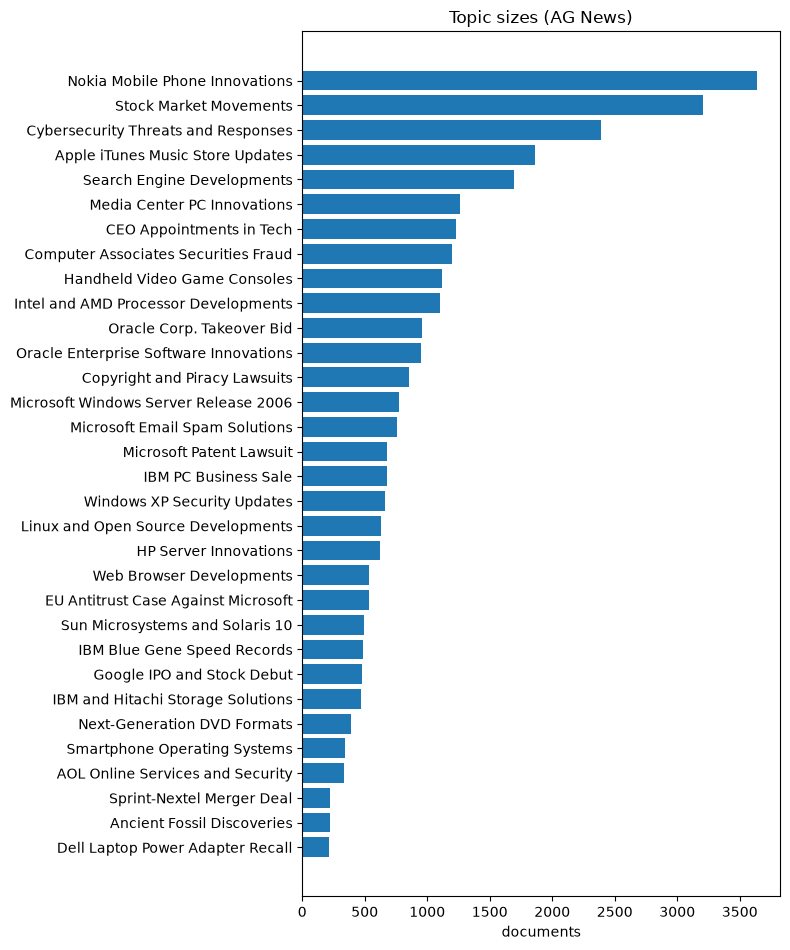

In [62]:
# Bar chart of how many documents each topic has.
fig, ax = plt.subplots(figsize=(8, max(4, 0.3 * len(topics_csv))))
plot_df = topics_csv.sort_values("n_docs")
ax.barh(plot_df["topic_name"], plot_df["n_docs"])
ax.set_xlabel("documents")
ax.set_title("Topic sizes (AG News)")
plt.tight_layout()
plt.savefig(OUTPUTS_DIR / "topic_sizes.png", dpi=150)
plt.show()

### 3.10 Summary of topic discovery

- Result: 32 topics built from 31,007 tech rows. After outlier reduction (35.1% of rows had no topic, now 0.0%), every row belongs to a topic. Topic sizes run from 213 to 3,640 rows.
- Names vs keywords: the names fit their keywords. A few are narrow, for example "Nokia Mobile Phone Innovations" also covers wireless and broadband.
- Junk keywords: none. The HTML leftovers ("href", "fullquote") no longer show up. The only odd keywords are the years 2005 and 2006 in the Windows Server topic, which are harmless.
- Not tech: 2 topics, "Stock Market Movements" (3,208 rows) and "Ancient Fossil Discoveries" (219 rows), together about 11% of the rows. "Computer Associates Securities Fraud" (1,196 rows) is borderline. These are rows the tech filter let through, as noted in the tech filter section, and we keep them.
- Topic count and chart: 32 topics is a little above the 15 to 30 target. The bar chart shows no single topic taking over. The two biggest are mobile and wireless, and the non-tech stock topic.

In [63]:
# Final summary.
print(f"Final topic count: {len(topics_csv)}")
print("Notebook 01 complete.")

Final topic count: 32
Notebook 01 complete.
